In [7]:
# imports
from os import system,path,listdir
from pathlib import Path
from collections import Counter
from gfagraphs import Graph
from matplotlib import pyplot as plt
from pandas import DataFrame
from statistics import mean, stdev

In [8]:
# variables
graph_paths:list[str] = [x for x in listdir('.') if x.endswith('.gfa')]
graph_ids:list[str] = [Path(x).stem for x in graph_paths]

In [9]:
# on télécharge l'executable
if not path.exists('./rs-pancat-paths'):
    system("wget https://github.com/dubssieg/rs-pancat-paths/releases/download/0.1.3/rs-pancat-paths")
    system("chmod +x rs-pancat-paths")

In [10]:
for i,x in enumerate(graph_paths):
    # calcul des nœuds ancres
    if not path.exists(f"len_{graph_ids[i]}.tsv"):
        system(f"./rs-pancat-paths {x} lengths > len_{graph_ids[i]}.tsv")

In [11]:
# calcul des valeurs de nœuds
values:list[list[int]] = [list() for _ in graph_ids]
for i,x in enumerate(graph_paths):
    with open(f"len_{graph_ids[i]}.tsv") as len_file:
        for line in len_file:
            if line.startswith('#'):
                continue
            else:
                values[i].append(int(line.strip().split('\t')[1]))

In [13]:
print("Nom\tµ\tσ")
for x,g in enumerate(values):
    print(f"{graph_ids[x]}\t{mean(values[x])}\t{stdev(values[x])}")

Nom	µ	σ
MC	11.066038006248387	130.94500879871177
PGGB	12.86664461838092	154.12849728025276


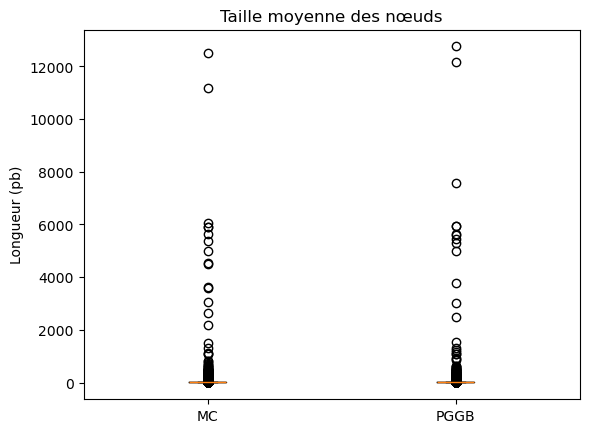

In [ ]:
# visualisation des nœuds ancres
plt.boxplot(values)
plt.title(f'Taille moyenne des nœuds')
plt.xticks(ticks=range(1,len(graph_ids)+1),labels=graph_ids)
plt.ylabel('Longueur (pb)')
plt.show()